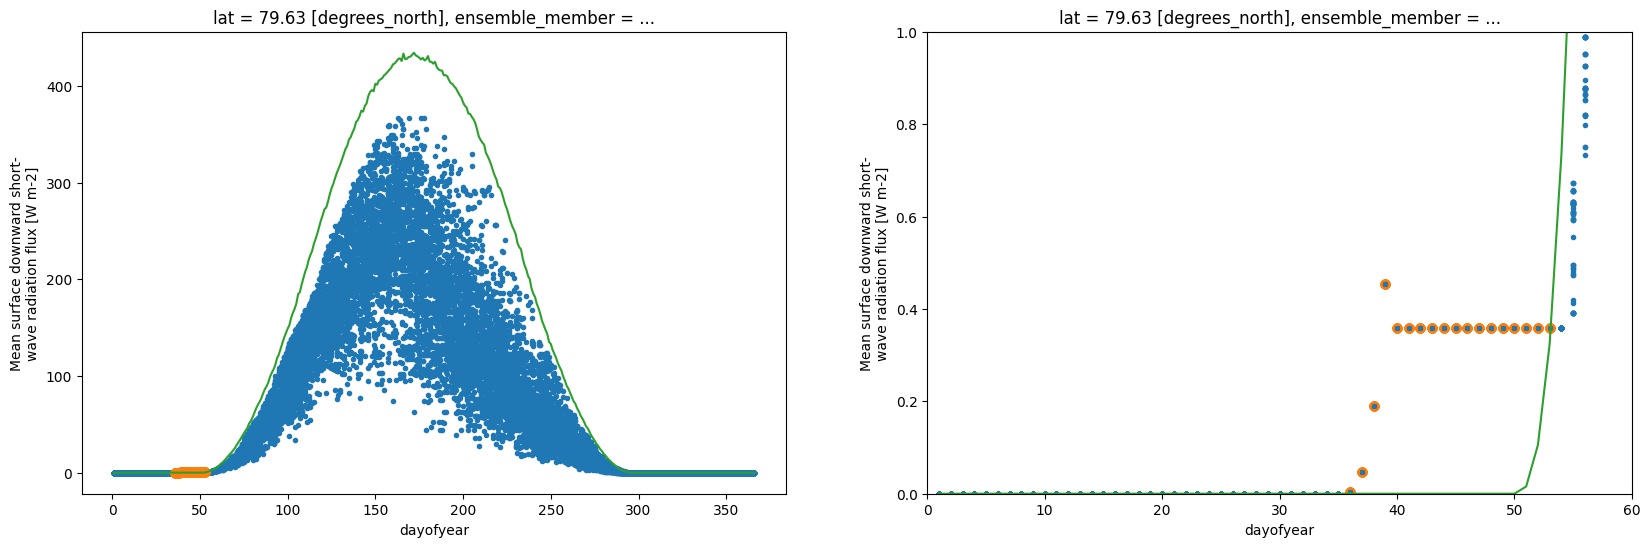

In [1]:
import matplotlib.pyplot as plt

from srm import catalog
from srm.utils import open_icechunk

# Settings
path_output = "s3://carbonplan-srm/output/production/CESM2-WACCM-ERA5-global.icechunk"
branch = "v0.11.1"
obs_cache_path = "s3://carbonplan-scratch/srm/bcsd-cache/production/CESM2-WACCM-ERA5-global.icechunk"
obs_branch = "v0.11.1"  # scratch/intermediate artifacts always live on "main", per ArtifactCache

var = "rsds"
ssp_ens = "008"
hist_ens = "r3i1p1f1"

ilat, ilon = 80, 0

# Load data
coarse_debiased_ssp = open_icechunk(
    path=path_output,
    branch=branch,
    group=f"debiased_coarse/ssp245/{var}/{ssp_ens}",
)[var]

coarse_obs = open_icechunk(
    path=obs_cache_path,
    branch=obs_branch,
    group=f"obs/{var}",
)[var]

raw_historical = (
    catalog.get("CESM2-WACCM").to_xarray()["historical"][var].sel(ensemble_member=hist_ens)
)

# --------------------------------------------------------------------- calc
# The maximum solar radiation on a given day of year for any gridcell is the same
# across longitudes, so max(dim="lon") is the plausibility ceiling at that lat/doy.
coarse_ssp_pt = coarse_debiased_ssp.sel(lon=ilon, lat=ilat, method="nearest")

max_value_obs = (
    coarse_obs.sel(lat=ilat, method="nearest")
    .max(dim="lon")
    .groupby("time.dayofyear")
    .max(dim="time")
    .load()
)
max_value_gcm = (
    raw_historical.isel(time=slice(1, None))
    .sel(lat=ilat, method="nearest")
    .max(dim="lon")
    .groupby("time.dayofyear")
    .max(dim="time")
    .load()
)
max_value_strict = max_value_obs.where(max_value_obs > max_value_gcm, max_value_gcm)

threshold = max_value_strict.sel(dayofyear=coarse_ssp_pt["time.dayofyear"])



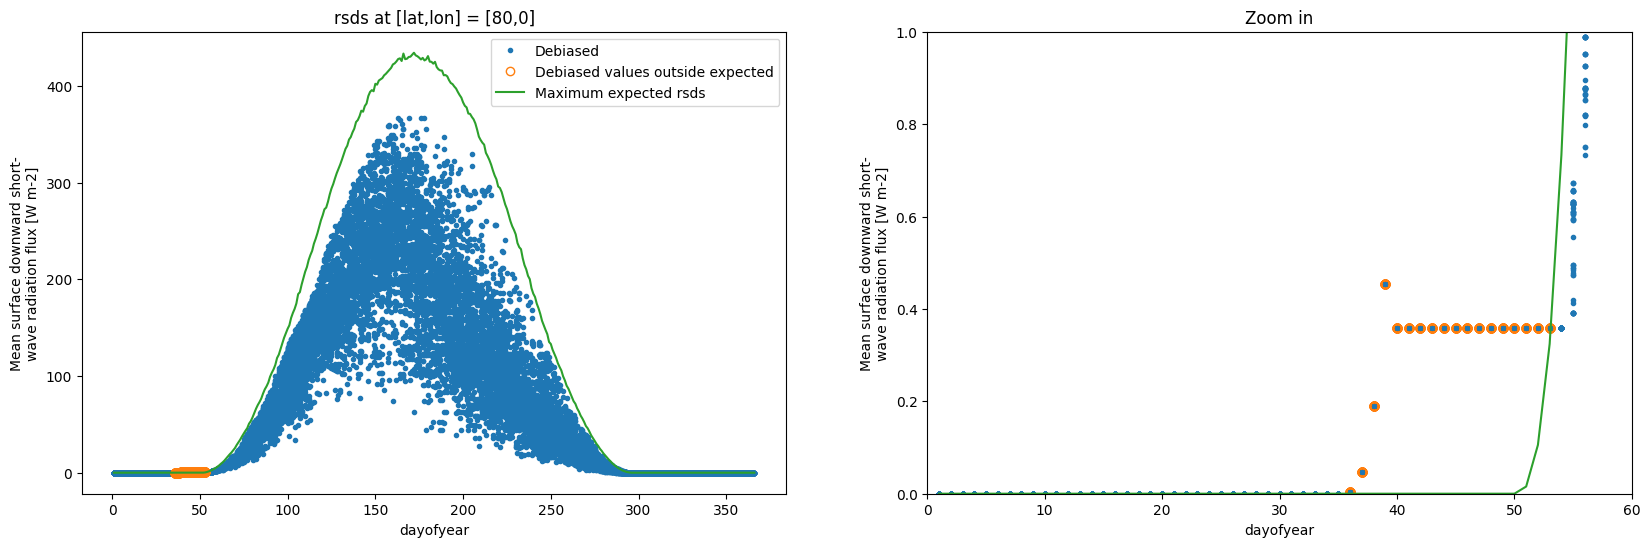

In [6]:
# Make figure
fig, axes = plt.subplots(ncols=2, figsize=(20, 6))

axes[0].plot(coarse_ssp_pt["time.dayofyear"], coarse_ssp_pt, ".",
            label='Debiased')
axes[0].plot(
    coarse_ssp_pt["time.dayofyear"],
    coarse_ssp_pt.where(coarse_ssp_pt > threshold),
    "o",
    fillstyle="none",
    label='Debiased values outside expected'
)
max_value_strict.plot(ax=axes[0], label='Maximum expected rsds')
axes[0].set_title('rsds at [lat,lon] = [80,0]')
axes[0].legend()

axes[1].plot(coarse_ssp_pt["time.dayofyear"], coarse_ssp_pt, ".")
axes[1].plot(
    coarse_ssp_pt["time.dayofyear"],
    coarse_ssp_pt.where(coarse_ssp_pt > threshold),
    "o",
    fillstyle="none",
)
axes[1].set_xlim([0, 60])
axes[1].set_ylim([0, 1])
max_value_strict.plot(ax=axes[1])
axes[1].set_title('Zoom in')
plt.show()
